** Note **

My derivations, plots, and code will be listed at the bottom of the notebook page.

# ME5311 Your first CFD problem 

This example solves a steady-state 1D conduction problem. From a partial differential equation point of view, the equation is elliptic. The discretization in the example is based on the finite-volume method. 

The program is structured as follows, which is a recommendated form of programming when solving physical problems. 

1. List all the physical parameters % L, k, q, TA, TB
2. Define all the numerical paramters % N, dx, cell center location x(N)
3. Setting up A matrix: first setting up the interior points, then boundary points
4. Setting up b vector: first setting up the interior points, then boundary points
5. Solve for T
6. Plot T as a function of x, and potentially compared with analytical solutions. 

In [110]:
## Load necessary packages
import numpy as np
import matplotlib.pyplot as plt

In [111]:
##Physical and numerical parameters
L = 0.02; # m, length of the 1D domain
k = 0.5; # W/mK, thermal conductivity of the material
q = 1000000; # W/m3, volumetric heat release rate
TA = 100; #Celsius, left boundary at fixed temperature
TB = 200; #Celsius, right boundary at fixed temperature
## Numerical Paramteres
N = 5; # number of cells during discretization 
dx = L/N; # length of each computational cell
Xc = np.zeros(N); # coordinates at the center of each cell
for i in range(0, N):
        Xc[i] = i*dx + 0.5*dx

qsrc=np.zeros(N);

for i in range(0,N):
    qsrc[i] = q; # A constant heat source term for the conduction problem
   
print(qsrc)

[1000000. 1000000. 1000000. 1000000. 1000000.]


In [112]:
## Set up the A matrix. 
## Note that A is a mostly zero (sparse matrix), so we first fill A with all zero entries. 
A = np.zeros((N,N));
for i in range(1,N-1):
    A[i,i] = -2*k/dx;
    A[i,i+1] = k/dx; # The first index indicates cell ID
    A[i,i-1] = k/dx; # The second index indicates the cells involved
# for left boundary
A[0,0] = -3*k/dx;
A[0,1] = k/dx;
# for right boundary
A[N-1,N-1] = -3*k/dx;
A[N-1,N-2] = k/dx;
#print(A)

In [113]:
## Set up b vector
b=np.zeros(N);
for i in range(1,N-1):
    b[i] = -qsrc[i]*dx;
#left boundary
    b[0] = -qsrc[0]*dx - 2*k*TA/dx;
#right boundary
    b[N-1] = -qsrc[N-1]*dx -2*k*TB/dx;
#print(b)

In [114]:
# solve for Temperature
T = np.linalg.solve(A,b)
#print(T)

In [115]:
# analytical solution for steady-state 1D conduction with a constant source q
def analytical_solution(x,q,L,k,TA,TB):
    return -q/2/k*x*x + (TB-TA+q*L*L/2/k)*x/L+TA

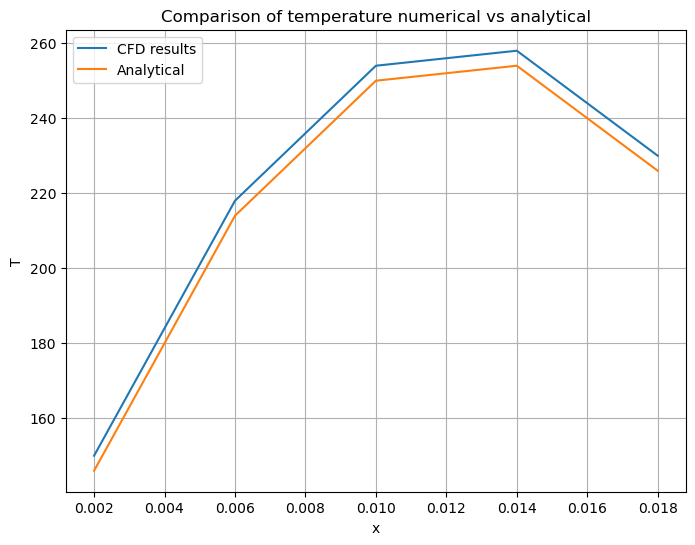

In [116]:
# plot the results 
analytical_results = analytical_solution(Xc,q,L,k,TA,TB) 
plt.figure(figsize=(8, 6))
plt.plot(Xc, T, label='CFD results')
plt.plot(Xc, analytical_results, label='Analytical') 

plt.xlabel('x')
plt.ylabel('T')
plt.title('Comparison of temperature numerical vs analytical')
plt.legend()
plt.grid()
plt.show()

## Exercise 1 
Increase the number of cells by changing the parameter in the first block and observe the agreement between the analytical and numerical solution. 

## Exercise 2
Modify the code to accomodate a convection boundary condition on the left hand side: convective heat transfer coefficient is 100 W/m2K and free stream temperature is 60 C. TA is unknown under the convective boundary condition. Hint: re-derive the discretized equation for cell 1 (the first cell on the left) and modify A and b to accomodate the solution. 

### #1 Solution ###

First to increase the number of cells, the variable N is increased from 5 to 10. The rest of the code format is kept the same since it is robust to a change in N.

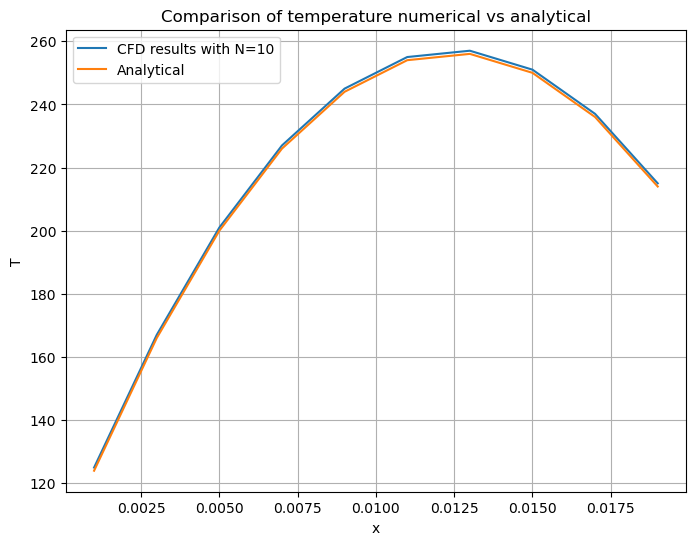

In [117]:
##Physical and numerical parameters
L = 0.02; # m, length of the 1D domain
k = 0.5; # W/mK, thermal conductivity of the material
q = 1000000; # W/m3, volumetric heat release rate
TA = 100; #Celsius, left boundary at fixed temperature
TB = 200; #Celsius, right boundary at fixed temperature
## Numerical Paramteres
N = 10; # number of cells during discretization --- *** Changed to 10 from 5 *** ---
dx = L/N; # length of each computational cell
Xc = np.zeros(N); # coordinates at the center of each cell
for i in range(0, N):
        Xc[i] = i*dx + 0.5*dx
qsrc=np.zeros(N);
for i in range(0,N):
    qsrc[i] = q; # A constant heat source term for the conduction problem
## Set up the A matrix. 
## Note that A is a mostly zero (sparse matrix), so we first fill A with all zero entries. 
A = np.zeros((N,N));
for i in range(1,N-1):
    A[i,i] = -2*k/dx;
    A[i,i+1] = k/dx; # The first index indicates cell ID
    A[i,i-1] = k/dx; # The second index indicates the cells involved
# for left boundary
A[0,0] = -3*k/dx;
A[0,1] = k/dx;
# for right boundary
A[N-1,N-1] = -3*k/dx;
A[N-1,N-2] = k/dx;
## Set up b vector
b=np.zeros(N);
for i in range(1,N-1):
    b[i] = -qsrc[i]*dx;
#left boundary
    b[0] = -qsrc[0]*dx - 2*k*TA/dx;
#right boundary
    b[N-1] = -qsrc[N-1]*dx -2*k*TB/dx;
# solve for Temperature
T = np.linalg.solve(A,b)
# analytical solution for steady-state 1D conduction with a constant source q
def analytical_solution(x,q,L,k,TA,TB):
    return -q/2/k*x*x + (TB-TA+q*L*L/2/k)*x/L+TA
# plot the results 
analytical_results = analytical_solution(Xc,q,L,k,TA,TB) 
plt.figure(figsize=(8, 6))
plt.plot(Xc, T, label='CFD results with N=10') # edited to reflect new element count
plt.plot(Xc, analytical_results, label='Analytical') 
plt.xlabel('x')
plt.ylabel('T')
plt.title('Comparison of temperature numerical vs analytical')
plt.legend()
plt.grid()
plt.show()

### Analysis - Ex. 1

Visually, there is much closer agreement between the analytical and numerical solutions with N=10 than N=5. Further doubling of the element count shows the lines essentially collinear.

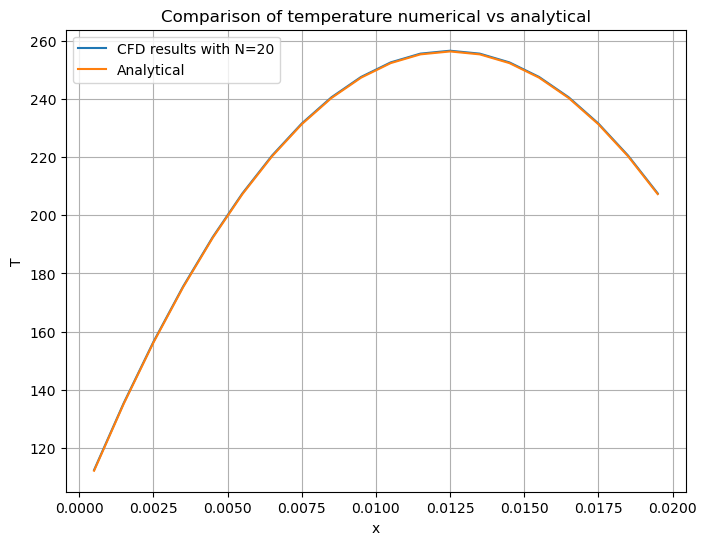

In [118]:
##Physical and numerical parameters
L = 0.02; # m, length of the 1D domain
k = 0.5; # W/mK, thermal conductivity of the material
q = 1000000; # W/m3, volumetric heat release rate
TA = 100; #Celsius, left boundary at fixed temperature
TB = 200; #Celsius, right boundary at fixed temperature
## Numerical Paramteres
N = 20; # number of cells during discretization --- *** Changed to 20 from 10 *** ---
dx = L/N; # length of each computational cell
Xc = np.zeros(N); # coordinates at the center of each cell
for i in range(0, N):
        Xc[i] = i*dx + 0.5*dx
qsrc=np.zeros(N);
for i in range(0,N):
    qsrc[i] = q; # A constant heat source term for the conduction problem
## Set up the A matrix. 
## Note that A is a mostly zero (sparse matrix), so we first fill A with all zero entries. 
A = np.zeros((N,N));
for i in range(1,N-1):
    A[i,i] = -2*k/dx;
    A[i,i+1] = k/dx; # The first index indicates cell ID
    A[i,i-1] = k/dx; # The second index indicates the cells involved
# for left boundary
A[0,0] = -3*k/dx;
A[0,1] = k/dx;
# for right boundary
A[N-1,N-1] = -3*k/dx;
A[N-1,N-2] = k/dx;
## Set up b vector
b=np.zeros(N);
for i in range(1,N-1):
    b[i] = -qsrc[i]*dx;
#left boundary
    b[0] = -qsrc[0]*dx - 2*k*TA/dx;
#right boundary
    b[N-1] = -qsrc[N-1]*dx -2*k*TB/dx;
# solve for Temperature
T = np.linalg.solve(A,b)
# analytical solution for steady-state 1D conduction with a constant source q
def analytical_solution(x,q,L,k,TA,TB):
    return -q/2/k*x*x + (TB-TA+q*L*L/2/k)*x/L+TA
# plot the results 
analytical_results = analytical_solution(Xc,q,L,k,TA,TB) 
plt.figure(figsize=(8, 6))
plt.plot(Xc, T, label='CFD results with N=20') # edited to reflect new element count
plt.plot(Xc, analytical_results, label='Analytical') 
plt.xlabel('x')
plt.ylabel('T')
plt.title('Comparison of temperature numerical vs analytical')
plt.legend()
plt.grid()
plt.show()

### #2 Solution

The first problem is a numerical solution to the 1D steady-state conduction equation with the form
$$
k\frac{\partial^2 T}{\partial x^2}+q=0
$$
which, using FVM discretization simplifies to 
$$
\left(\frac{k}{\Delta x}\right)T_{i-1}+\left(-\frac{2k}{\Delta x}\right)T_i+\left(\frac{k}{\Delta x}\right)T_{i+1}=-q\Delta x
$$
in the center of the grid,
$$
\left(-\frac{3k}{\Delta x}\right)T_0+\left(\frac{k}{\Delta x}\right)T_1=-q\Delta x-\frac{2kT_A}{\Delta x}
$$
at the left boundary, and
$$
\left(\frac{k}{\Delta x}\right)T_{N-2}+\left(-\frac{3k}{\Delta x}\right)T_{N-1}=-q\Delta x-\frac{2kT_B}{\Delta x}
$$
at the right boundary, where $q$ represents a constant heat addition term, and $T_A$, $T_B$ are the boundary temperatures.

In exercise 2, I am tasked to change the left boundary condition to convection following the structure
$$
q"_{conv}=h(T_{\infty}-T_S),
$$
where $h=100\text{ }W/m\cdot K$, $T_{\infty}=60^\circ C$. 

This is incorporated into the left wall boundary condition by leveraging the 1D heat flux conservation, assuming the boundary has zero thickness and the heat source term only acts on the nodes themselves, allowing for:
$$
q"_{conv,\infty\rightarrow S}=q"_{cond,S\rightarrow T_0}
$$
$$
h(T_{\infty}-T_S)=k\frac{T_S-T_0}{\Delta x/2}
$$
$$
T_S=\frac{hT_{\infty}+\frac{2k}{\Delta x}T_0}{h+\frac{2k}{\Delta x}}
$$
$$
q"_{conv}=h\left(T_{\infty}-\frac{hT_{\infty}+\frac{2k}{\Delta x}T_0}{h+\frac{2k}{\Delta x}}\right)
$$
$$
=\left(\frac{h\cdot\frac{2k}{\Delta x}}{h+\frac{2k}{\Delta x}}\right)(T_{\infty}-T_0)
$$
$$
\text{Flux in}-\text{Flux out}+\text{Source}=0
$$
$$
\rightarrow \left(\frac{h\cdot\frac{2k}{\Delta x}}{h+\frac{2k}{\Delta x}}\right)(T_{\infty}-T_0)-\frac{k}{\Delta x}(T_0-T_1)+q\Delta x=0
$$
$$
\left[-\left(\frac{k}{\Delta x}+\frac{h\cdot\frac{2k}{\Delta x}}{h+\frac{2k}{\Delta x}}\right)\right]T_0+\left(\frac{k}{\Delta x}\right)T_1=-q\Delta x-\left(\frac{h\cdot\frac{2k}{\Delta x}}{h+\frac{2k}{\Delta x}}\right)T_{\infty}.
$$

This can now be implemented into the original code, the only difference being the $A_{0,0}$, $A_{0,1}$, and $b_{0}$ elements in the system matrices.





In [119]:
##Physical and numerical parameters
L = 0.02; # m, length of the 1D domain
k = 0.5; # W/mK, thermal conductivity of the material
q = 1000000; # W/m3, volumetric heat release rate
h = 100; # W/m2K, convective heat transfer coefficient at the left boundary
Tinf = 60; #Celsius, left boundary at fixed temperature
TB = 200; #Celsius, right boundary at fixed temperature
## Numerical Paramteres
N = 20; # number of cells during discretization. using 20 as it produced better results as shown in prolem 1.
dx = L/N; # length of each computational cell
Xc = np.zeros(N); # coordinates at the center of each cell
for i in range(0, N):
        Xc[i] = i*dx + 0.5*dx
qsrc=np.zeros(N);
for i in range(0,N):
    qsrc[i] = q; # A constant heat source term for the conduction problem

In [120]:
## Set up the A matrix. 
## Note that A is a mostly zero (sparse matrix), so we first fill A with all zero entries. 
A = np.zeros((N,N));
for i in range(1,N-1):
    A[i,i] = -2*k/dx;
    A[i,i+1] = k/dx; # The first index indicates cell ID
    A[i,i-1] = k/dx; # The second index indicates the cells involved
# for left boundary
A[0,0] = -(k/dx + (h * (2*k/dx)) / (h + (2*k/dx))); # New left BC as affects T_0
A[0,1] = k/dx;
# for right boundary
A[N-1,N-1] = -3*k/dx;
A[N-1,N-2] = k/dx;

In [121]:
## Set up b vector
b=np.zeros(N);
for i in range(1,N-1):
    b[i] = -qsrc[i]*dx;
#left boundary
    b[0] = -qsrc[0]*dx - ((h * (2*k/dx)) / (h + (2*k/dx)))*Tinf; # New left BC RHS
#right boundary
    b[N-1] = -qsrc[N-1]*dx -2*k*TB/dx;

In [122]:
# solve for Temperature
T = np.linalg.solve(A,b)

A new analytical solution is required. Using the form
$$
T(x)=-\frac{q}{2k}x^2+C_1x+C_2,
$$
the new boundary conditions are imposed to find that
$$
C_1 = \frac{T_B - T_\infty + \frac{qL^2}{2k} + \frac{qL}{h}}{L + \frac{k}{h}}, \quad C_2 = T_\infty + \frac{k C_1}{h}.
$$

In [123]:
def analytical_solution_exercise2(x, q, L, k, h, T_inf, TB):
    # Constant C1: No extra source terms here
    C1 = (TB - T_inf + (q * L**2 / (2 * k))) / (L + k / h)
    
    # Constant C2: Purely related to fluid temp and surface gradient
    C2 = T_inf + (k / h) * C1
    
    return -(q / (2 * k)) * x**2 + C1 * x + C2

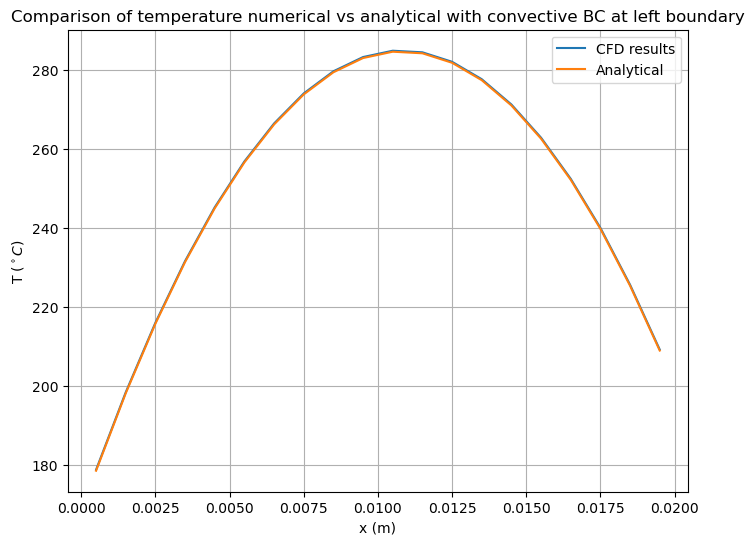

In [124]:
# plot the results 
analytical_results = analytical_solution_exercise2(Xc,q,L,k,h,Tinf,TB) 
plt.figure(figsize=(8, 6))
plt.plot(Xc, T, label='CFD results')
plt.plot(Xc, analytical_results, label='Analytical') 

plt.xlabel('x (m)')
plt.ylabel(r'T ($^\circ C$)')
plt.title('Comparison of temperature numerical vs analytical with convective BC at left boundary')
plt.legend()
plt.grid()
plt.show()